In [41]:
# Instalación (si no está instalado)
!pip install ydata-profiling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# Configuración de visualización
plt.style.use('ggplot')
sns.set(style="whitegrid")
%matplotlib inline

url = "https://www.datos.gov.co/api/views/shu7-uqse/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)
print("Dimensiones:", df.shape)

print("Dimensiones originales:", df.shape)
display(df.head(3))
print("\nInformación del dataset:")
df.info()
print("\nEstadísticas descriptivas básicas:")
display(df.describe(include='all'))

Dimensiones: (1858, 11)
Dimensiones originales: (1858, 11)


,FECHA DE INICIO,FECHA FINAL,DEPARTAMENTO,MUNICIPIO,FUERZA O ENTIDAD,ENTIDAD VINCULADA,PROCESO DE GESTIÓN DEL RIESGO,ACTIVIDAD REALIZADA,MEDIOS EQUIPOS/PLATAFORMAS EMPLEADOS,CANTIDAD DE MEDIOS EMPLEADOS,PERSONAL EMPLEADO
0,01/01/2024 12:00:00 AM,01/01/2024 12:00:00 AM,VALLE DEL CAUCA,CALI,EJÉRCITO NACIONAL,ENTIDADES DEL SNGRD,REDUCCIÓN DEL RIESGO,PODA O CORTE DE ARBOLES,MOTOSIERRA,1.0,23
1,01/01/2024 12:00:00 AM,01/02/2024 12:00:00 AM,CUNDINAMARCA,NILO,EJÉRCITO NACIONAL,ENTIDADES DEL SNGRD,REDUCCIÓN DEL RIESGO,PODA O CORTE DE ARBOLES,MOTOSIERRA,1.0,32
2,01/01/2024 12:00:00 AM,01/03/2024 12:00:00 AM,ANTIOQUIA,MEDELLÍN,EJÉRCITO NACIONAL,ENTIDADES DEL SNGRD,MANEJO DE DESASTRES,APOYO EXTINCIÓN INCENDIO FORESTAL,FTR,1.0,22



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1858 entries, 0 to 1857
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   FECHA DE INICIO                       1858 non-null   object 
 1   FECHA FINAL                           1858 non-null   object 
 2   DEPARTAMENTO                          1858 non-null   object 
 3   MUNICIPIO                             1858 non-null   object 
 4   FUERZA O ENTIDAD                      1858 non-null   object 
 5   ENTIDAD VINCULADA                     1740 non-null   object 
 6   PROCESO DE GESTIÓN DEL RIESGO         1858 non-null   object 
 7   ACTIVIDAD REALIZADA                   1858 non-null   object 
 8   MEDIOS EQUIPOS/PLATAFORMAS EMPLEADOS  1856 non-null   object 
 9   CANTIDAD DE MEDIOS EMPLEADOS          1856 non-null   float64
 10  PERSONAL EMPLEADO                     1858 non-null   int6

,FECHA DE INICIO,FECHA FINAL,DEPARTAMENTO,MUNICIPIO,FUERZA O ENTIDAD,ENTIDAD VINCULADA,PROCESO DE GESTIÓN DEL RIESGO,ACTIVIDAD REALIZADA,MEDIOS EQUIPOS/PLATAFORMAS EMPLEADOS,CANTIDAD DE MEDIOS EMPLEADOS,PERSONAL EMPLEADO
count,1858,1858,1858,1858,1858,1740,1858,1858,1856,1856.000000,1858.000000
unique,326,329,32,290,3,33,2,32,70,NaN,NaN
top,10/02/2024 12:00:00 AM,10/02/2024 12:00:00 AM,LA GUAJIRA,RIOHACHA,EJÉRCITO NACIONAL,ENTIDADES DEL SNGRD,MANEJO DE DESASTRES,ASISTENCIA HUMANITARIA,OTROS,NaN,NaN
freq,33,33,481,261,1266,1266,1121,697,540,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.096983,12.181916
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.603915,10.205759
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,6.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,11.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,14.000000


#  Eliminación de duplicados



In [33]:
print("\n--- ELIMINACIÓN DE DUPLICADOS ---")
dups_antes = df.duplicated().sum()
print(f"Duplicados antes: {dups_antes}")
df = df.drop_duplicates()
print(f"Duplicados después: {df.duplicated().sum()}")


ELIMINACION ANTES: 356
ELIMINACION DESPUES: 0


# Ajuste de tipos de datos

In [43]:
print("\n--- CONVERSIÓN DE FECHAS ---")
# Primero intentamos con dayfirst=True (formato dd/mm/yyyy)
df['FECHA DE INICIO'] = pd.to_datetime(df['FECHA DE INICIO'], errors='coerce', dayfirst=True)
df['FECHA FINAL'] = pd.to_datetime(df['FECHA FINAL'], errors='coerce', dayfirst=True)
# Si aún hay muchos NaT, se puede intentar con formato automático (pandas >=2.0)
# df['FECHA DE INICIO'] = pd.to_datetime(df['FECHA DE INICIO'], errors='coerce', infer_datetime_format=True)
print(f"Nulos en fechas después de conversión: Inicio={df['FECHA DE INICIO'].isna().sum()}, Final={df['FECHA FINAL'].isna().sum()}")


--- CONVERSIÓN DE FECHAS ---
Nulos en fechas después de conversión: Inicio=0, Final=0


/tmp/ipykernel_6827/3260370954.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FECHA DE INICIO'] = pd.to_datetime(df['FECHA DE INICIO'], errors='coerce', dayfirst=True)
/tmp/ipykernel_6827/3260370954.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FECHA FINAL'] = pd.to_datetime(df['FECHA FINAL'], errors='coerce', dayfirst=True)


# Tratamiento de valores nulos

In [45]:
# 3.3 Tratamiento de valores nulos
print("\n--- TRATAMIENTO DE NULOS ---")
# Porcentaje inicial de nulos
nulos_porcentaje = df.isnull().mean() * 100
print("Porcentaje de nulos por columna (antes de imputar):")
print(nulos_porcentaje[nulos_porcentaje > 0])

# Imputar MEDIOS EQUIPOS/PLATAFORMAS EMPLEADOS (categórica)
df['MEDIOS EQUIPOS/PLATAFORMAS EMPLEADOS'] = df['MEDIOS EQUIPOS/PLATAFORMAS EMPLEADOS'].fillna('Sin información')

# Imputar CANTIDAD DE MEDIOS EMPLEADOS con la mediana (robusta)
mediana_medios = df['CANTIDAD DE MEDIOS EMPLEADOS'].median()
df['CANTIDAD DE MEDIOS EMPLEADOS'] = df['CANTIDAD DE MEDIOS EMPLEADOS'].fillna(mediana_medios)

# Imputar PERSONAL EMPLEADO (si tiene nulos) con la mediana
if df['PERSONAL EMPLEADO'].isnull().any():
    mediana_personal = df['PERSONAL EMPLEADO'].median()
    df['PERSONAL EMPLEADO'] = df['PERSONAL EMPLEADO'].fillna(mediana_personal)

# Eliminar filas con fechas nulas (pocas, no afectan significativamente)
filas_antes = len(df)
df = df.dropna(subset=['FECHA DE INICIO', 'FECHA FINAL'])
print(f"Filas eliminadas por fechas nulas: {filas_antes - len(df)}")


--- TRATAMIENTO DE NULOS ---
Porcentaje de nulos por columna (antes de imputar):
ENTIDAD VINCULADA    6.350915
dtype: float64
Filas eliminadas por fechas nulas: 0


# Corrección de inconsistencias con replace y map

In [47]:
departamentos_map = {
    'Bogota D.C.': 'Bogotá D.C.',
    'BOGOTA': 'Bogotá D.C.',
    'bogota': 'Bogotá D.C.',
    'Antioquia': 'Antioquia',
    'ANTIOQUIA': 'Antioquia',
    'Valle': 'Valle del Cauca',
    'VALLE': 'Valle del Cauca'
}
df['DEPARTAMENTO'] = df['DEPARTAMENTO'].replace(departamentos_map)

# Estandarizar PROCESO DE GESTIÓN DEL RIESGO
procesos_map = {
    'Mitigación': 'Mitigación',
    'MITIGACION': 'Mitigación',
    'mitigación': 'Mitigación',
    'Prevención': 'Prevención',
    'PREVENCION': 'Prevención',
    'Respuesta': 'Respuesta',
    'RESPUESTA': 'Respuesta',
    'Rehabilitación': 'Rehabilitación',
    'REHABILITACION': 'Rehabilitación'
}
df['PROCESO DE GESTIÓN DEL RIESGO'] = df['PROCESO DE GESTIÓN DEL RIESGO'].replace(procesos_map)

# Detección y tratamiento de valores atípicos


--- DETECCIÓN DE OUTLIERS ---


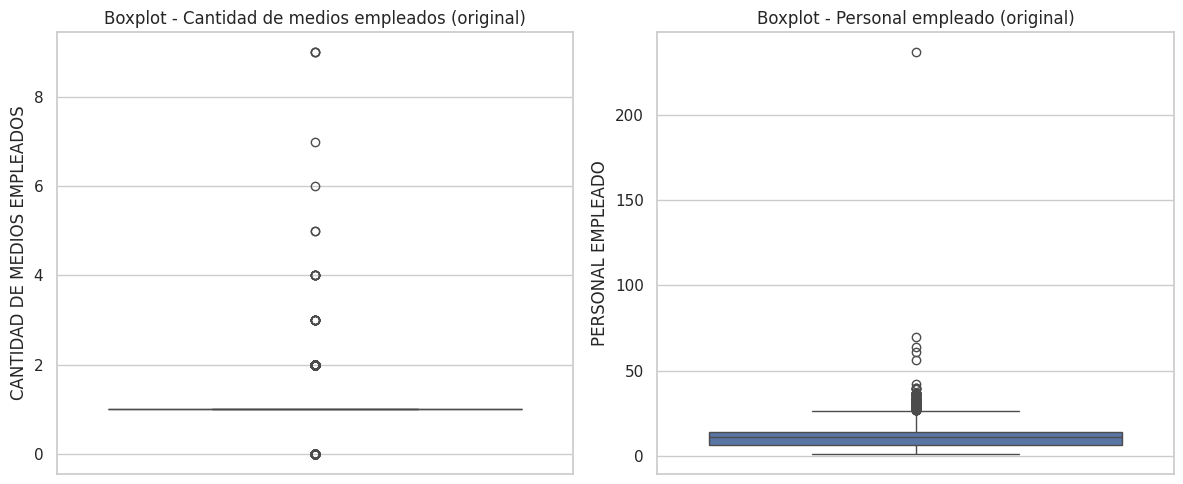

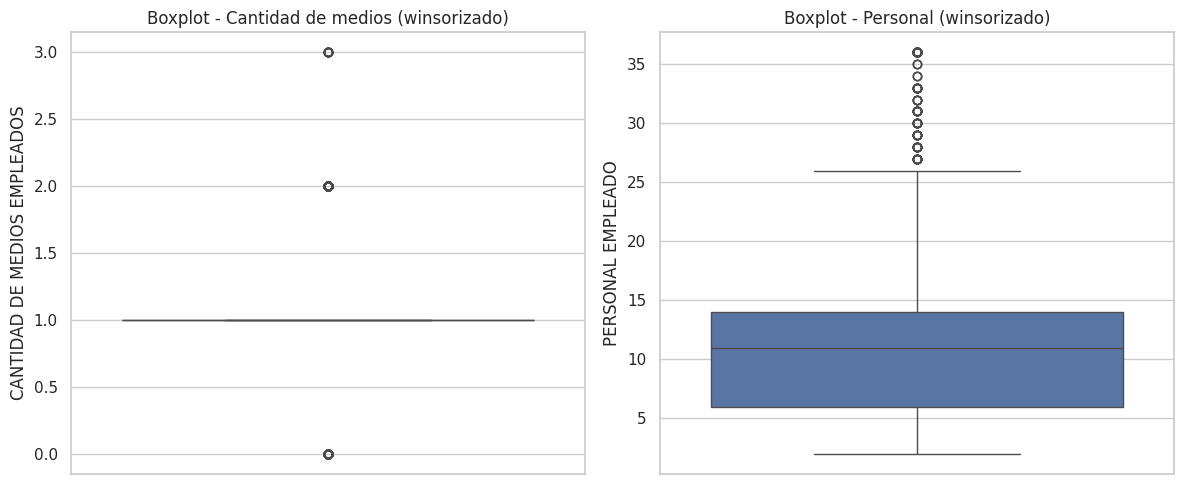

Outliers tratados con winsorización (percentiles 1% y 99%).

--- AGREGACIÓN DE DATOS (GRANULARIDAD MENSUAL POR DEPARTAMENTO Y PROCESO) ---
Dataset agregado (granularidad mensual por departamento y proceso):
Dimensiones: (385, 8)


,DEPARTAMENTO,PROCESO DE GESTIÓN DEL RIESGO,AÑO_MES,total_actividades,total_medios,total_personal,promedio_medios,promedio_personal
0,AMAZONAS,MANEJO DE DESASTRES,2024-04,1,1.0,7,1.000000,7.000000
1,AMAZONAS,MANEJO DE DESASTRES,2024-12,1,1.0,4,1.000000,4.000000
2,ARAUCA,MANEJO DE DESASTRES,2024-03,4,6.0,51,1.500000,12.750000
3,ARAUCA,MANEJO DE DESASTRES,2024-04,9,14.0,148,1.555556,16.444444
4,ARAUCA,MANEJO DE DESASTRES,2024-05,1,1.0,3,1.000000,3.000000



--- VALIDACIÓN DE CALIDAD DEL DATASET LIMPIO ---
1. Completitud de datos:
   - Nulos en columnas críticas (df original limpio):
     FECHA DE INICIO: 0
     DEPARTAMENTO: 0
     CANTIDAD MEDIOS: 0
     PERSONAL: 0
   - Dataset agregado sin nulos: 0 nulos en total.

2. Relevancia para la pregunta de negocio:
   - Pregunta: ¿Cómo varía el uso de recursos (medios y personal) en los procesos de gestión del riesgo a lo largo del tiempo y entre departamentos?
   - Variables relevantes incluidas en df_agg: DEPARTAMENTO, PROCESO DE GESTIÓN DEL RIESGO, AÑO_MES, total_medios, total_personal, promedio_medios, promedio_personal.
   - La granularidad mensual permite análisis temporal suficiente para detectar tendencias estacionales.

3. Granularidad:
   - Original: actividad diaria (alta granularidad).
   - Transformada: mensual por departamento y proceso (granularidad media).
   - Justificación: responde a la necesidad de comparar recursos a nivel mensual sin ruido diario, permitiendo agregación 

In [48]:
print("\n--- DETECCIÓN DE OUTLIERS ---")
# Función para winsorización (limitar a percentiles)
def winsorize_series(series, lower_percentile=0.01, upper_percentile=0.99):
    lower = series.quantile(lower_percentile)
    upper = series.quantile(upper_percentile)
    return series.clip(lower, upper)

# Visualizar con boxplots antes de tratar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['CANTIDAD DE MEDIOS EMPLEADOS'], ax=axes[0])
axes[0].set_title('Boxplot - Cantidad de medios empleados (original)')
sns.boxplot(y=df['PERSONAL EMPLEADO'], ax=axes[1])
axes[1].set_title('Boxplot - Personal empleado (original)')
plt.tight_layout()
plt.show()

# Aplicar winsorización (en lugar de eliminar)
df['CANTIDAD DE MEDIOS EMPLEADOS'] = winsorize_series(df['CANTIDAD DE MEDIOS EMPLEADOS'], 0.01, 0.99)
df['PERSONAL EMPLEADO'] = winsorize_series(df['PERSONAL EMPLEADO'], 0.01, 0.99)

# Verificar después
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['CANTIDAD DE MEDIOS EMPLEADOS'], ax=axes[0])
axes[0].set_title('Boxplot - Cantidad de medios (winsorizado)')
sns.boxplot(y=df['PERSONAL EMPLEADO'], ax=axes[1])
axes[1].set_title('Boxplot - Personal (winsorizado)')
plt.tight_layout()
plt.show()

print("Outliers tratados con winsorización (percentiles 1% y 99%).")

# 3.7 Agregación de datos (cambio de granularidad)
print("\n--- AGREGACIÓN DE DATOS (GRANULARIDAD MENSUAL POR DEPARTAMENTO Y PROCESO) ---")
# Crear columna año-mes
df['AÑO_MES'] = df['FECHA DE INICIO'].dt.to_period('M')

# Agrupar por departamento, proceso y mes
df_agg = df.groupby(['DEPARTAMENTO', 'PROCESO DE GESTIÓN DEL RIESGO', 'AÑO_MES']).agg(
    total_actividades=('ACTIVIDAD REALIZADA', 'count'),
    total_medios=('CANTIDAD DE MEDIOS EMPLEADOS', 'sum'),
    total_personal=('PERSONAL EMPLEADO', 'sum'),
    promedio_medios=('CANTIDAD DE MEDIOS EMPLEADOS', 'mean'),
    promedio_personal=('PERSONAL EMPLEADO', 'mean')
).reset_index()

# Convertir AÑO_MES a string para mejor visualización
df_agg['AÑO_MES'] = df_agg['AÑO_MES'].astype(str)

print("Dataset agregado (granularidad mensual por departamento y proceso):")
print(f"Dimensiones: {df_agg.shape}")
display(df_agg.head())

# ============================================================
# IV. VALIDACIÓN
# ============================================================
print("\n--- VALIDACIÓN DE CALIDAD DEL DATASET LIMPIO ---")

# 4.1 Completitud
print("1. Completitud de datos:")
print(f"   - Nulos en columnas críticas (df original limpio):")
print(f"     FECHA DE INICIO: {df['FECHA DE INICIO'].isnull().sum()}")
print(f"     DEPARTAMENTO: {df['DEPARTAMENTO'].isnull().sum()}")
print(f"     CANTIDAD MEDIOS: {df['CANTIDAD DE MEDIOS EMPLEADOS'].isnull().sum()}")
print(f"     PERSONAL: {df['PERSONAL EMPLEADO'].isnull().sum()}")
print(f"   - Dataset agregado sin nulos: {df_agg.isnull().sum().sum()} nulos en total.")

# 4.2 Relevancia de las variables
print("\n2. Relevancia para la pregunta de negocio:")
print("   - Pregunta: ¿Cómo varía el uso de recursos (medios y personal) en los procesos de gestión del riesgo a lo largo del tiempo y entre departamentos?")
print("   - Variables relevantes incluidas en df_agg: DEPARTAMENTO, PROCESO DE GESTIÓN DEL RIESGO, AÑO_MES, total_medios, total_personal, promedio_medios, promedio_personal.")
print("   - La granularidad mensual permite análisis temporal suficiente para detectar tendencias estacionales.")

# 4.3 Granularidad adecuada
print("\n3. Granularidad:")
print("   - Original: actividad diaria (alta granularidad).")
print("   - Transformada: mensual por departamento y proceso (granularidad media).")
print("   - Justificación: responde a la necesidad de comparar recursos a nivel mensual sin ruido diario, permitiendo agregación por proceso y ubicación.")

# 4.4 Verificación de consistencia
print("\n4. Consistencia de categorías:")
print(f"   - Departamentos únicos después de estandarización: {df_agg['DEPARTAMENTO'].nunique()}")
print(f"   - Procesos únicos: {df_agg['PROCESO DE GESTIÓN DEL RIESGO'].nunique()}")
print("   - Rango de fechas:", df['FECHA DE INICIO'].min(), "a", df['FECHA DE INICIO'].max())

print("\n--- LIMPIEZA Y TRANSFORMACIÓN COMPLETADAS CON ÉXITO ---")
print(f"Dataset original: {len(df)} filas, {df.shape[1]} columnas (después de limpieza).")
print(f"Dataset agregado: {len(df_agg)} filas, {df_agg.shape[1]} columnas.")